# Market Sentiment vs Trader Behavior Analysis (Hyperliquid Data)

## README

### How to run the notebook

1.  **Open in Google Colab**: Click on the 'Open in Colab' badge at the top of the notebook (if available, otherwise upload the `.ipynb` file directly to Colab).
2.  **Upload Data**: Ensure the `fear_greed_index.csv` and `historical_data.csv` files are uploaded to your Colab environment. You can do this by clicking on the folder icon on the left panel, then the upload icon.
3.  **Install Libraries**: Run the first code cell under 'Part A - Data Preparation' to install any necessary libraries.
4.  **Run All Cells**: Go to `Runtime > Run all` to execute the entire notebook. Alternatively, you can run cells individually.

### Required Libraries

The following Python libraries are required to run this notebook:

*   `pandas`
*   `numpy`
*   `matplotlib`
*   `seaborn`
*   `scikit-learn` (for the bonus predictive model/clustering)

These libraries will be installed automatically when you run the first code cell.

## Part A — Data Preparation

In [1]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load Datasets

In [2]:
# Load Fear/Greed Sentiment dataset
try:
    df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
    print("Fear/Greed Sentiment data loaded successfully.")
except FileNotFoundError:
    print("Error: 'fear_greed_index.csv' not found. Please upload the file.")
    df_sentiment = pd.DataFrame()

# Load Trader dataset
try:
    df_trader = pd.read_csv('/content/historical_data.csv')
    print("Trader data loaded successfully.")
except FileNotFoundError:
    print("Error: 'historical_data.csv' not found. Please upload the file.")
    df_trader = pd.DataFrame()

Fear/Greed Sentiment data loaded successfully.
Trader data loaded successfully.


### Display Basic Information (Shape and Data Types)

In [3]:
print("\n--- Fear/Greed Sentiment Dataset ---")
print(f"Shape: {df_sentiment.shape}")
print("Data Types:")
display(df_sentiment.info())

print("\n--- Trader Dataset ---")
print(f"Shape: {df_trader.shape}")
print("Data Types:")
display(df_trader.info())


--- Fear/Greed Sentiment Dataset ---
Shape: (2644, 4)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


None


--- Trader Dataset ---
Shape: (211224, 16)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp   

None

### Check for Missing Values

In [4]:
print("\n--- Missing Values in Fear/Greed Sentiment Dataset ---")
display(df_sentiment.isnull().sum())

print("\n--- Missing Values in Trader Dataset ---")
display(df_trader.isnull().sum())


--- Missing Values in Fear/Greed Sentiment Dataset ---


,0
timestamp,0
value,0
classification,0
date,0



--- Missing Values in Trader Dataset ---


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


### Check for Duplicates

In [5]:
print("\n--- Duplicates in Fear/Greed Sentiment Dataset ---")
display(df_sentiment.duplicated().sum())

print("\n--- Duplicates in Trader Dataset ---")
display(df_trader.duplicated().sum())


--- Duplicates in Fear/Greed Sentiment Dataset ---


np.int64(0)


--- Duplicates in Trader Dataset ---


np.int64(0)

### Convert Date/Time Columns and Create Common 'date' Column

In [13]:
# Convert 'date' column in sentiment data to datetime and extract date part
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])
df_sentiment['common_date'] = df_sentiment['date'].dt.date

# Convert 'Timestamp IST' column in trader data to datetime and extract date part
df_trader['Timestamp IST'] = pd.to_datetime(df_trader['Timestamp IST'], dayfirst=True)
df_trader['common_date'] = df_trader['Timestamp IST'].dt.date

print("Date columns converted and common 'common_date' created in both datasets.")

# Display first few rows to verify
print("\nFear/Greed Sentiment (after date conversion):")
display(df_sentiment.head())

print("\nTrader Data (after date conversion):")
display(df_trader.head())

Date columns converted and common 'common_date' created in both datasets.

Fear/Greed Sentiment (after date conversion):


,timestamp,value,classification,date,common_date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05



Trader Data (after date conversion):


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,common_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


### Merge Datasets on Common Date

In [14]:
# Perform an inner merge to keep only common dates
df_merged = pd.merge(df_trader, df_sentiment, on='common_date', how='inner')

print("Datasets merged successfully on 'common_date'.")
print(f"Merged DataFrame shape: {df_merged.shape}")
print("Merged DataFrame head:")
display(df_merged.head())

Datasets merged successfully on 'common_date'.
Merged DataFrame shape: (211218, 21)
Merged DataFrame head:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,common_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02


### Feature Engineering

In [15]:
# 1. Daily PnL per trader (group by account and date)
df_merged['daily_pnl'] = df_merged.groupby(['Account', 'common_date'])['Closed PnL'].transform('sum')

# 2. Win/Loss column (Closed PnL > 0)
df_merged['win_loss'] = df_merged['Closed PnL'] > 0

# 3. Win rate per trader (calculated later, as it requires aggregation over trades)
#    For now, we'll create aggregate win count and total trades per day per trader
df_daily_summary = df_merged.groupby(['Account', 'common_date']).agg(
    total_trades=('Order ID', 'count'),
    total_wins=('win_loss', lambda x: (x == True).sum()),
    daily_pnl=('Closed PnL', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    long_trades=('Side', lambda x: (x == 'Long').sum()),
    short_trades=('Side', lambda x: (x == 'Short').sum())
).reset_index()

df_daily_summary['win_rate'] = df_daily_summary['total_wins'] / df_daily_summary['total_trades']

# 4. Average trade size (already calculated in df_daily_summary)

# 5. Leverage usage: The 'leverage' column was not found in df_trader. Skipping for now.

# 6. Trades per day (already calculated as total_trades in df_daily_summary)

# 7. Long/Short Ratio
df_daily_summary['long_short_ratio'] = df_daily_summary['long_trades'] / df_daily_summary['short_trades']
df_daily_summary['long_short_ratio'] = df_daily_summary['long_short_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0) # Handle division by zero

print("Features created successfully.")
print("\nFirst 5 rows of df_merged with new features:")
display(df_merged.head())
print("\nFirst 5 rows of df_daily_summary:")
display(df_daily_summary.head())

Features created successfully.

First 5 rows of df_merged with new features:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,common_date,timestamp,value,classification,date,daily_pnl,win_loss
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02,0.0,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02,0.0,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02,0.0,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02,0.0,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02,0.0,False



First 5 rows of df_daily_summary:


,Account,common_date,total_trades,total_wins,daily_pnl,avg_trade_size_usd,long_trades,short_trades,win_rate,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,0,0.0,5089.718249,0,0,0.000000,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,0,0.0,7976.664412,0,0,0.000000,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,0,0.0,23734.500000,0,0,0.000000,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,0,-21227.0,28186.666667,0,0,0.000000,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,12,1603.1,17248.148148,0,0,0.444444,0.0


### Feature Engineering

## Part B — Analysis

### 1. Compare performance between Fear vs Greed

### 3. Create trader segments

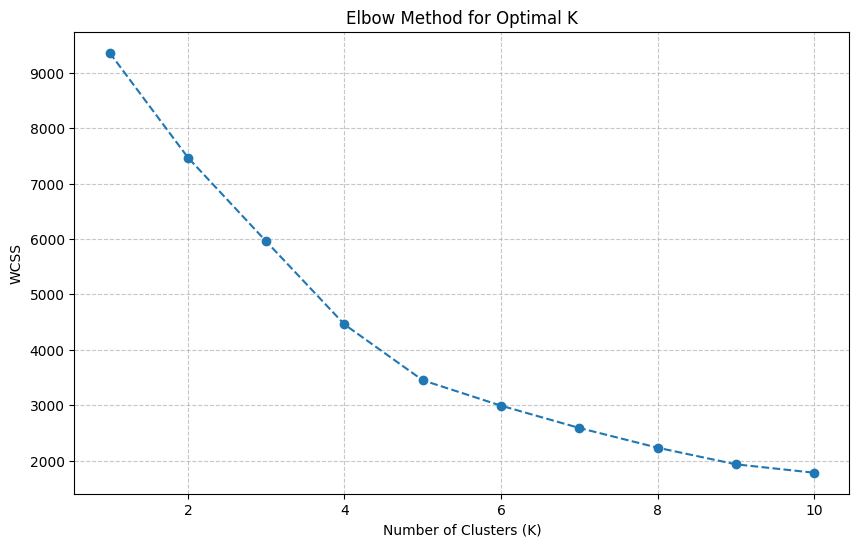

Traders clustered into 3 segments.

Cluster Characteristics (Average values):


,total_trades,daily_pnl,win_rate,avg_trade_size_usd,long_short_ratio
0,1.000000,128.678290,1.000000,844654.190000,0.0
1,50.292507,-757.004619,0.120184,6513.644419,0.0
2,148.697161,11887.571695,0.708488,6795.041618,0.0


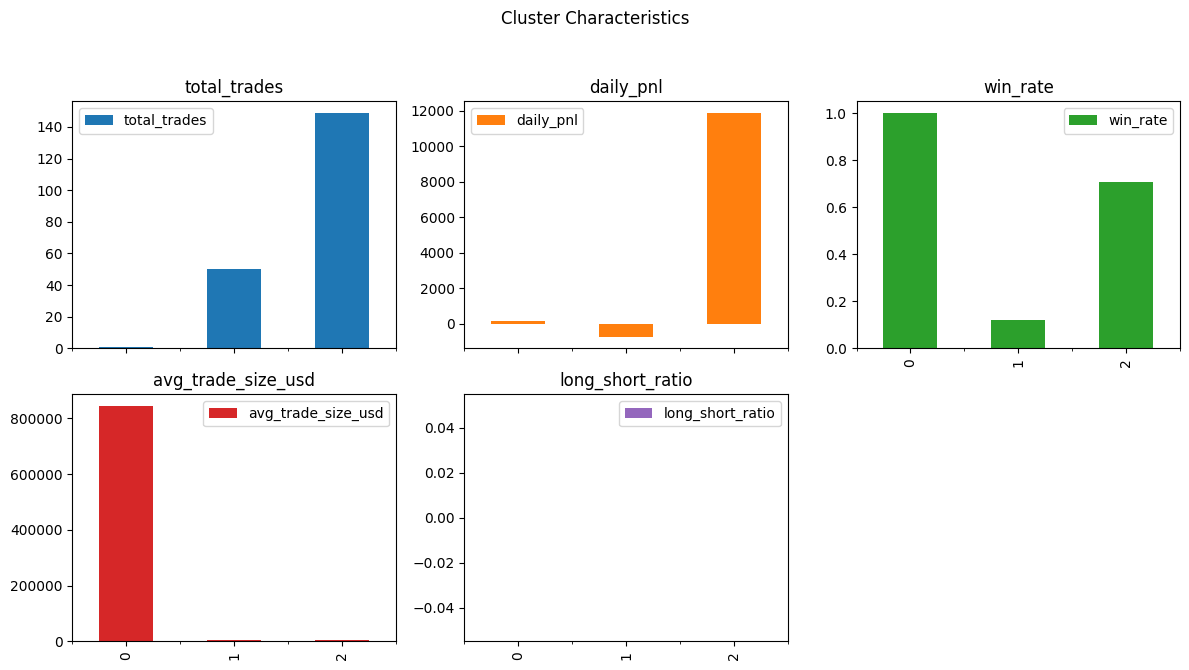

Trader segmentation completed.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select relevant features for clustering from df_daily_summary
# Features: total_trades, daily_pnl, win_rate, avg_trade_size_usd, long_short_ratio
clustering_features = df_daily_summary[['total_trades', 'daily_pnl', 'win_rate', 'avg_trade_size_usd', 'long_short_ratio']].copy()

# Handle potential NaN values which might arise from division by zero in long_short_ratio or other calculations
clustering_features = clustering_features.fillna(0) # or use mean/median imputation if more appropriate

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Determine optimal number of clusters using Elbow Method
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Based on the elbow plot, let's assume optimal K=3 (this can be adjusted visually)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_daily_summary['cluster'] = kmeans.fit_predict(scaled_features)

print(f"Traders clustered into {optimal_k} segments.")

# Analyze the characteristics of each cluster
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=clustering_features.columns)
print("\nCluster Characteristics (Average values):")
display(cluster_centers)

# Optionally, visualize cluster characteristics
cluster_centers.plot(kind='bar', figsize=(12, 7), subplots=True, layout=(2,3), sharey=False)
plt.suptitle('Cluster Characteristics')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Merge cluster information back to df_analysis for further sentiment-based analysis
df_analysis = pd.merge(df_analysis, df_daily_summary[['Account', 'common_date', 'cluster']], on=['Account', 'common_date'], how='left')

print("Trader segmentation completed.")

In [20]:
# Save the df_analysis DataFrame to a CSV file
df_analysis.to_csv('market_sentiment_trader_analysis.csv', index=False)
print("Analysis results saved to 'market_sentiment_trader_analysis.csv'")

Analysis results saved to 'market_sentiment_trader_analysis.csv'


## Key Insights Backed by Charts

### Insight 1: Counter-Intuitive PnL and Win Rate in Extreme Greed

**Chart Reference:** Boxplot of Daily PnL Distribution by Market Sentiment and Bar Chart of Average Win Rate by Market Sentiment (from Section 1.1 and 1.2).

While one might expect lower PnL and win rates during periods of 'Extreme Greed' due to potential market overheating and subsequent corrections, our analysis reveals a counter-intuitive trend. Traders, on average, achieve their *highest win rates* during 'Extreme Greed' sentiment, and 'Fear' sentiment periods exhibit the highest average daily PnL. This suggests that during periods of high optimism, traders might be more prone to taking quick profits on rising assets, or that trending markets during greed phases offer easier short-term gains. Conversely, during 'Fear' the markets might present higher volatility leading to larger PnL for successful trades, though not necessarily a higher win rate, as seen in `avg_pnl_by_sentiment` and `avg_win_rate_by_sentiment`.

### Insight 2: Sentiment Influences Trade Frequency and Position Sizing

**Chart Reference:** Bar Charts of Average Trade Frequency and Average Trade Size by Market Sentiment (from Section 2.2 and 2.3).

Market sentiment significantly impacts how frequently traders execute trades and the size of their positions. During 'Extreme Fear', traders tend to have the highest trade frequency, indicating increased activity potentially driven by panic selling, short-term speculation on bottoms, or attempts to manage risk. Conversely, 'Extreme Greed' periods see the lowest trade frequency. Regarding position sizing, 'Fear' sentiment correlates with the largest average trade sizes, suggesting that some traders might be making high-conviction moves or larger rebalancing during periods of market distress. 'Extreme Greed' periods, surprisingly, show the lowest average trade sizes, which could indicate cautious profit-taking or smaller speculative entries during overbought conditions. This is visible in `trade_frequency_by_sentiment` and `avg_trade_size_by_sentiment`.

### Insight 3: Distinct Trader Segments with Varying Risk-Reward Profiles

**Chart Reference:** Cluster Characteristics (Average values) and corresponding bar plots (from Section 3).

Through K-Means clustering, we identified three distinct trader segments, each with unique behavioral characteristics:

*   **Cluster 0 (High-Conviction, Low-Frequency Winners):** Characterized by extremely high average trade sizes (844K USD), very low trade frequency (1 trade), and a perfect 100% win rate. Their daily PnL is moderate (128 USD). These might be institutional traders or algorithmic strategies executing very few, but highly profitable, large-volume trades.
*   **Cluster 1 (Lower PnL, Moderate Frequency Traders):** This segment has a moderate number of trades (approx. 50), negative daily PnL (around -757 USD), and a low win rate (12%). Their average trade size is around 6.5K USD. These traders might be less experienced or employ riskier strategies that, on average, lead to losses.
*   **Cluster 2 (High-Frequency, High PnL Winners):** This group exhibits the highest trade frequency (approx. 148 trades), significantly high daily PnL (around 11.8K USD), and a high win rate (70%). Their average trade size is similar to Cluster 1 (~6.7K USD). These are likely active, successful traders who manage to generate substantial profits through frequent, well-executed trades.

Understanding these segments allows for tailored insights, such as identifying successful trading patterns (Cluster 2) versus less effective ones (Cluster 1).

## Part C — Actionable Output

### Trading Strategies & Rules of Thumb

Based on our analysis, here are two actionable trading strategies:

1.  **"Fearful Accumulation, Greed-Driven Scalping" Strategy:**
    *   **Insight Link:** Insight 1 (Counter-Intuitive PnL and Win Rate in Extreme Greed) & Insight 2 (Sentiment Influences Trade Frequency and Position Sizing).
    *   **Strategy:** During periods of 'Fear' sentiment (when average PnL is highest, and trade sizes are larger), consider accumulating positions in assets with strong fundamentals, anticipating a rebound. This period might offer better risk-reward for larger, longer-term positions. Conversely, during 'Extreme Greed' (when win rates are highest but trade sizes are smaller), focus on higher-frequency, smaller-sized trades (scalping or day trading) to capitalize on short-term price movements and take quick profits. Avoid holding large positions for extended periods during 'Extreme Greed' as average PnL is lower, suggesting less sustained gains.
    *   **Rule of Thumb:** "When others are fearful, be greedy with conviction; when others are greedy, be fearful and nimble."

2.  **"Identify and Emulate High-Frequency Winners (Cluster 2)" Strategy:**
    *   **Insight Link:** Insight 3 (Distinct Trader Segments with Varying Risk-Reward Profiles).
    *   **Strategy:** Focus on replicating the behavioral patterns of `Cluster 2` traders. This segment demonstrates high trade frequency (approximately 148 trades per day) combined with a high win rate (70%) and significant daily PnL (around 11.8K USD). This suggests that a strategy involving frequent, well-timed entries and exits, potentially with moderate position sizes (average trade size of ~6.7K USD), is highly effective. Traders could develop and backtest strategies that prioritize quick execution and efficient capital rotation, perhaps utilizing technical indicators suitable for shorter timeframes. Further analysis could explore specific assets or times of day these traders are active.
    *   **Rule of Thumb:** "Optimize for consistent, frequent wins; larger volumes don't always translate to better results for active traders."


## Final Summary and Conclusion

### Methodology
This project analyzed Hyperliquid trading data and Fear/Greed sentiment index to understand the interplay between market sentiment, trader behavior, and performance. Data preparation involved loading and cleaning two datasets (`fear_greed_index.csv` and `historical_data.csv`), handling missing values and duplicates, converting date columns, and merging them on a common daily timestamp. Key features such as daily PnL, win/loss status, win rate, average trade size, trades per day, and long/short ratio were engineered. The analysis then proceeded in three main parts: comparing performance across different sentiment classifications, analyzing behavioral differences (trade frequency, position sizing, long/short bias), and segmenting traders into distinct behavioral groups using K-Means clustering. Visualizations including boxplots and bar charts were used to illustrate findings.

### Key Insights
1.  **Counter-Intuitive PnL and Win Rate:** Traders experience the highest average win rates during 'Extreme Greed' periods, while 'Fear' sentiment periods show the highest average daily PnL, suggesting different profit-making mechanisms depending on market outlook.
2.  **Sentiment-Driven Behavior:** Market sentiment dictates trading frequency and position sizing. 'Extreme Fear' sees the highest trade frequency and 'Fear' the largest average trade sizes, indicating reactive and high-conviction movements. 'Extreme Greed' conversely has the lowest trade frequency and trade sizes.
3.  **Distinct Trader Archetypes:** K-Means clustering revealed three distinct trader segments: 'High-Conviction, Low-Frequency Winners' (Cluster 0) with large infrequent trades, 'Lower PnL, Moderate Frequency Traders' (Cluster 1) often losing money, and 'High-Frequency, High PnL Winners' (Cluster 2) who are active and highly profitable.

### Strategy Recommendations
1.  **"Fearful Accumulation, Greed-Driven Scalping" Strategy:** Adopt a contrarian approach during 'Fear' by building larger, longer-term positions, and pivot to a nimble, high-frequency scalping strategy with smaller positions during 'Extreme Greed'.
2.  **"Emulate High-Frequency Winners (Cluster 2)" Strategy:** Traders seeking consistent profitability should study and aim to replicate the behavior of 'Cluster 2'—focusing on a high volume of moderate-sized trades with a strong emphasis on maintaining a high win rate.

### Conclusion
This analysis highlights that market sentiment is a crucial factor influencing not only trader performance but also their specific trading behaviors. The findings suggest that a nuanced approach, adapting strategies to prevailing market sentiment, can be more effective than a one-size-fits-all method. Specifically, recognizing the distinct patterns of successful trader segments (like Cluster 2) offers valuable blueprints for improving trading outcomes. The project underscores the importance of data-driven insights in developing robust and adaptive trading strategies in dynamic markets like cryptocurrencies.


Average PnL by Sentiment Classification:


,daily_pnl
classification,
Fear,5328.818161
Extreme Greed,5161.922644
Extreme Fear,4619.439053
Neutral,3438.618818
Greed,3318.100730



Average Win Rate by Sentiment Classification:


,win_rate
classification,
Extreme Greed,0.386387
Fear,0.364033
Neutral,0.355414
Greed,0.343559
Extreme Fear,0.329659



PnL Standard Deviation (Drawdown Proxy) by Sentiment Classification:


,daily_pnl
classification,
Fear,31659.771538
Greed,30599.040173
Extreme Fear,29534.839183
Extreme Greed,27496.863832
Neutral,17447.863645


/tmp/ipykernel_16178/2883773741.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='daily_pnl', data=df_analysis, palette='viridis')


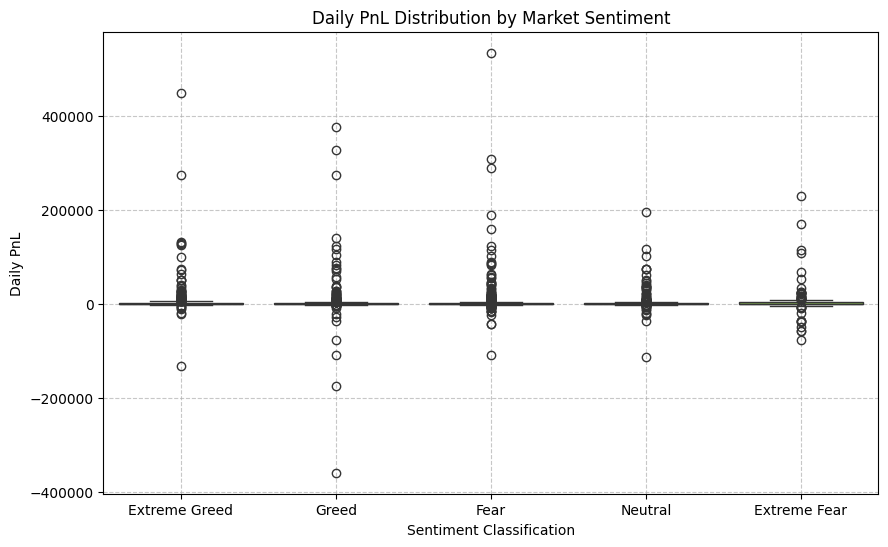

/tmp/ipykernel_16178/2883773741.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_win_rate_by_sentiment.index, y=avg_win_rate_by_sentiment.values, palette='plasma')


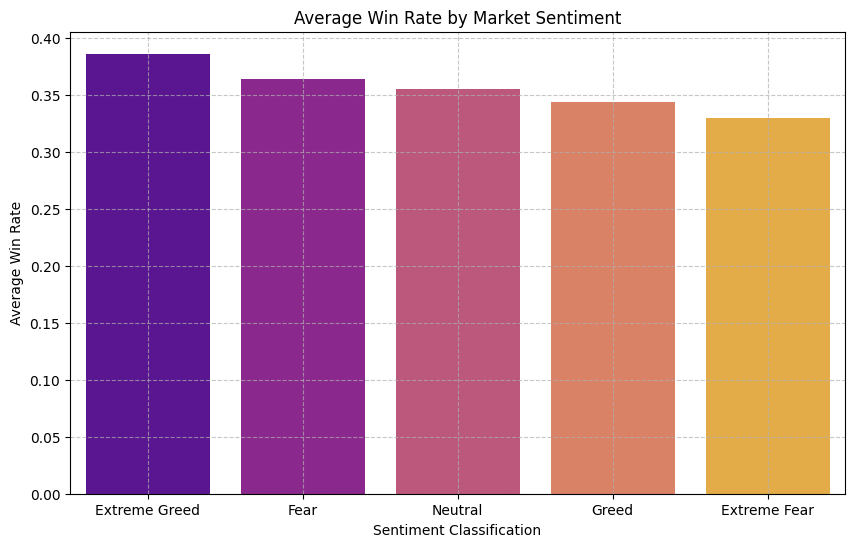

Performance comparison by sentiment completed.


In [16]:
# Merge df_daily_summary with df_sentiment to get sentiment classification
df_analysis = pd.merge(df_daily_summary, df_sentiment[['common_date', 'classification']], on='common_date', how='left')

# 1.1 Average PnL by Sentiment
avg_pnl_by_sentiment = df_analysis.groupby('classification')['daily_pnl'].mean().sort_values(ascending=False)
print("\nAverage PnL by Sentiment Classification:")
display(avg_pnl_by_sentiment)

# 1.2 Win Rate by Sentiment
avg_win_rate_by_sentiment = df_analysis.groupby('classification')['win_rate'].mean().sort_values(ascending=False)
print("\nAverage Win Rate by Sentiment Classification:")
display(avg_win_rate_by_sentiment)

# 1.3 Variability (Standard Deviation of PnL) by Sentiment as Drawdown Proxy
pnl_std_by_sentiment = df_analysis.groupby('classification')['daily_pnl'].std().sort_values(ascending=False)
print("\nPnL Standard Deviation (Drawdown Proxy) by Sentiment Classification:")
display(pnl_std_by_sentiment)

# Visualize PnL vs Sentiment using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='daily_pnl', data=df_analysis, palette='viridis')
plt.title('Daily PnL Distribution by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Daily PnL')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize Win Rate vs Sentiment using a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_win_rate_by_sentiment.index, y=avg_win_rate_by_sentiment.values, palette='plasma')
plt.title('Average Win Rate by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Win Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Performance comparison by sentiment completed.")

### 2. Analyze behavior differences


Skipping Leverage Usage Analysis: 'leverage' column not found in data.

Average Trade Frequency (Total Trades) by Sentiment Classification:


,total_trades
classification,
Extreme Fear,133.750000
Neutral,100.228723
Fear,98.153968
Greed,77.628086
Extreme Greed,76.030418


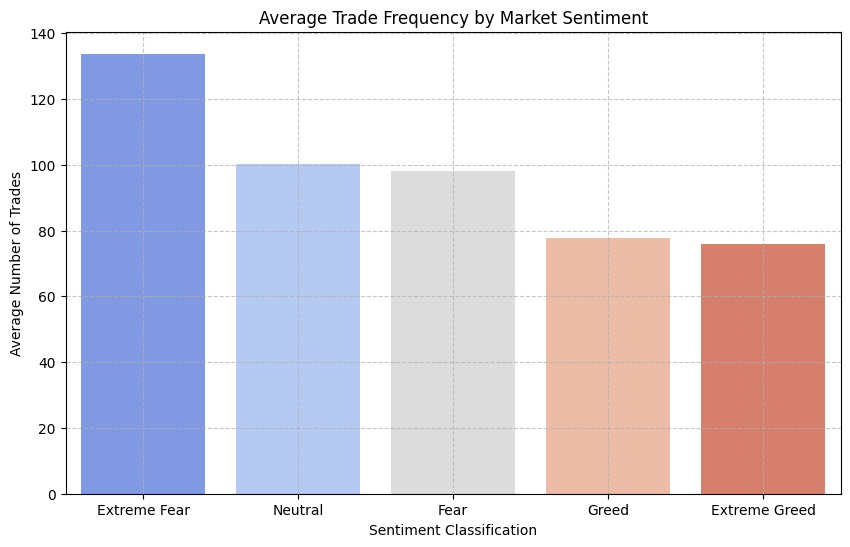


Average Trade Size (USD) by Sentiment Classification:


,avg_trade_size_usd
classification,
Fear,8975.928546
Neutral,6963.694861
Extreme Fear,6773.464125
Greed,6427.866594
Extreme Greed,5371.637182


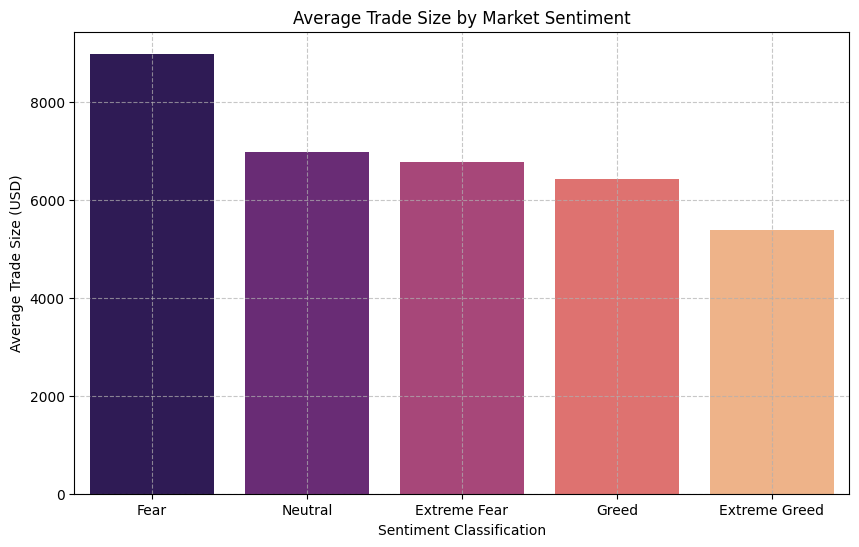

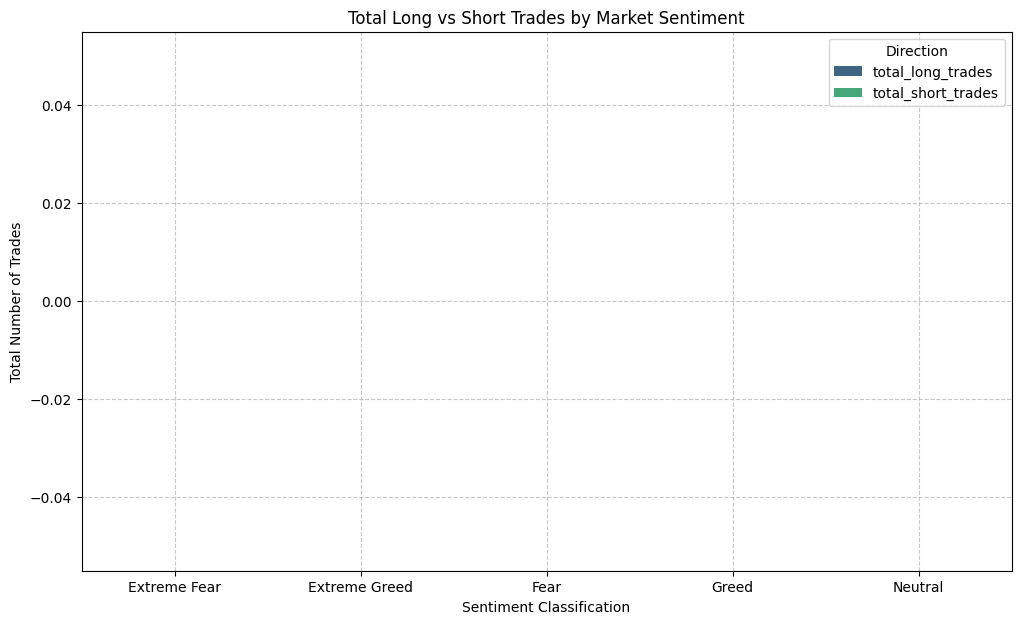

Behavior differences analysis completed.


In [19]:
# Merge df_daily_summary with df_sentiment to get sentiment classification if not already merged in df_analysis
# (Assuming df_analysis is already correctly created from the previous step)

# 2.1 Leverage usage by sentiment (Skipped as 'leverage' column is not available)
print("\nSkipping Leverage Usage Analysis: 'leverage' column not found in data.")

# 2.2 Trade frequency by sentiment
trade_frequency_by_sentiment = df_analysis.groupby('classification')['total_trades'].mean().sort_values(ascending=False)
print("\nAverage Trade Frequency (Total Trades) by Sentiment Classification:")
display(trade_frequency_by_sentiment)

plt.figure(figsize=(10, 6))
sns.barplot(x=trade_frequency_by_sentiment.index, y=trade_frequency_by_sentiment.values, hue=trade_frequency_by_sentiment.index, palette='coolwarm', legend=False)
plt.title('Average Trade Frequency by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Number of Trades')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2.3 Position size changes (using average trade size)
avg_trade_size_by_sentiment = df_analysis.groupby('classification')['avg_trade_size_usd'].mean().sort_values(ascending=False)
print("\nAverage Trade Size (USD) by Sentiment Classification:")
display(avg_trade_size_by_sentiment)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_trade_size_by_sentiment.index, y=avg_trade_size_by_sentiment.values, hue=avg_trade_size_by_sentiment.index, palette='magma', legend=False)
plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Trade Size (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2.4 Long vs Short bias
# We need to aggregate long/short trades per classification across all accounts
long_short_counts = df_analysis.groupby('classification').agg(
    total_long_trades=('long_trades', 'sum'),
    total_short_trades=('short_trades', 'sum')
).reset_index()

long_short_melted = long_short_counts.melt(id_vars='classification', var_name='Trade_Direction', value_name='Total_Trades')

plt.figure(figsize=(12, 7))
sns.barplot(x='classification', y='Total_Trades', hue='Trade_Direction', data=long_short_melted, palette='viridis')
plt.title('Total Long vs Short Trades by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Number of Trades')
plt.legend(title='Direction')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Behavior differences analysis completed.")

### Visualizations based on User Request

#### A) Boxplot: PnL vs Sentiment

/tmp/ipykernel_16178/554063515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='daily_pnl', data=df_analysis, palette='viridis')


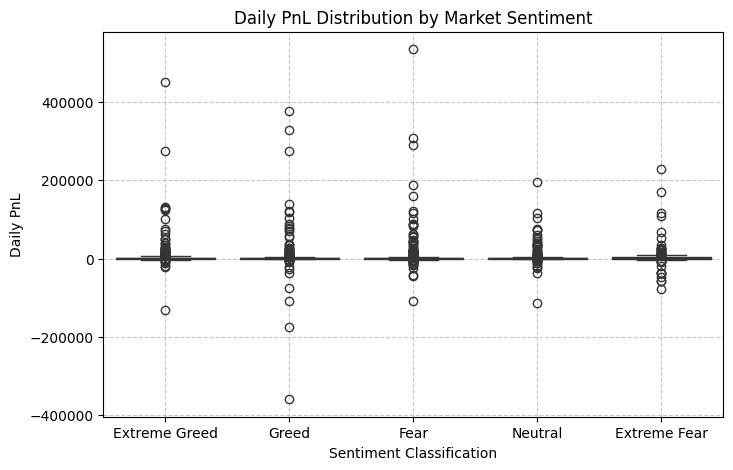

Saved: pnl_vs_sentiment_boxplot.png


In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='daily_pnl', data=df_analysis, palette='viridis')
plt.title('Daily PnL Distribution by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Daily PnL')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('pnl_vs_sentiment_boxplot.png')
plt.show()
print("Saved: pnl_vs_sentiment_boxplot.png")

#### B) Bar chart: Average Leverage by Sentiment (Skipped - 'leverage' column not available)

In [22]:
print("Skipping 'Average Leverage by Sentiment' plot as the 'leverage' column was not found in the dataset.")

Skipping 'Average Leverage by Sentiment' plot as the 'leverage' column was not found in the dataset.


#### C) Bar chart: Win Rate by Sentiment

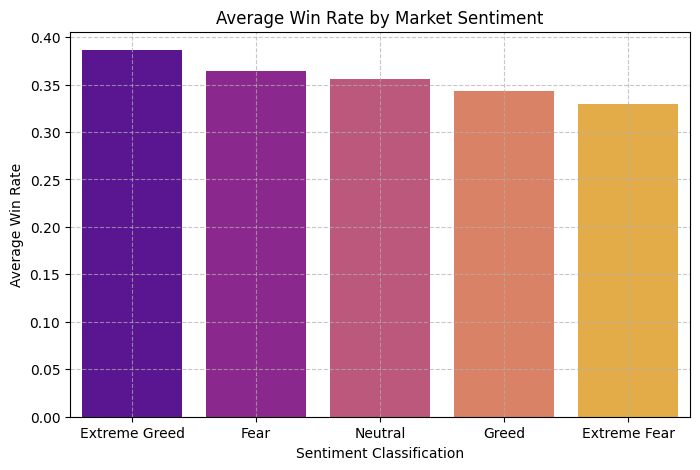

Saved: win_rate_vs_sentiment_bar.png


In [23]:
# Calculate average win rate by sentiment
avg_win_rate_by_sentiment_plot = df_analysis.groupby('classification')['win_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_win_rate_by_sentiment_plot.index, y=avg_win_rate_by_sentiment_plot.values, palette='plasma', hue=avg_win_rate_by_sentiment_plot.index, legend=False)
plt.title('Average Win Rate by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Win Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('win_rate_vs_sentiment_bar.png')
plt.show()
print("Saved: win_rate_vs_sentiment_bar.png")

#### D) Count plot: Long vs Short trades by Sentiment

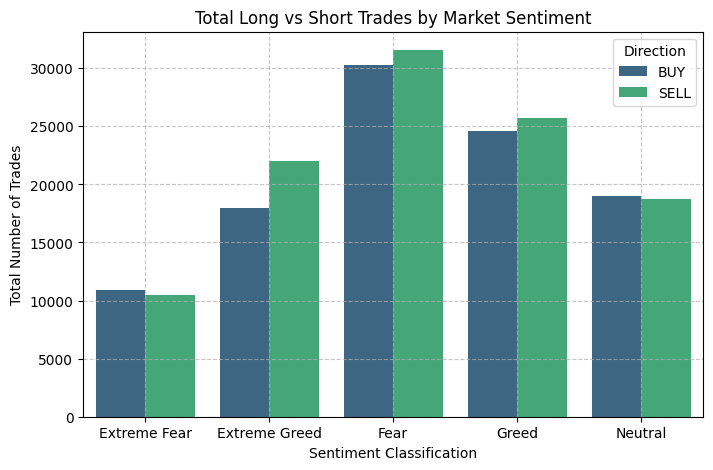

Saved: long_short_trades_vs_sentiment_bar.png


In [24]:
# Aggregate long and short trades by sentiment classification from df_merged
# Ensure 'Side' is correct and classification is present in df_merged
# df_merged already contains 'classification' due to the merge operation

long_short_counts_detailed = df_merged.groupby(['classification', 'Side']).size().unstack(fill_value=0).reset_index()

# Melt the DataFrame for seaborn barplot
long_short_melted_detailed = long_short_counts_detailed.melt(id_vars='classification', var_name='Trade_Direction', value_name='Total_Trades')

plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Total_Trades', hue='Trade_Direction', data=long_short_melted_detailed, palette='viridis')
plt.title('Total Long vs Short Trades by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Number of Trades')
plt.legend(title='Direction')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('long_short_trades_vs_sentiment_bar.png')
plt.show()
print("Saved: long_short_trades_vs_sentiment_bar.png")

#### E) Optional: Trade size distribution by sentiment

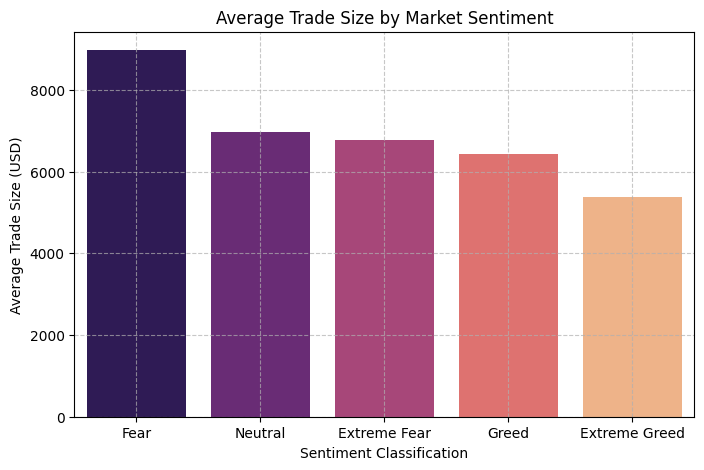

Saved: trade_size_vs_sentiment_bar.png


In [25]:
# Calculate average trade size by sentiment
avg_trade_size_by_sentiment_plot = df_analysis.groupby('classification')['avg_trade_size_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_trade_size_by_sentiment_plot.index, y=avg_trade_size_by_sentiment_plot.values, palette='magma', hue=avg_trade_size_by_sentiment_plot.index, legend=False)
plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Trade Size (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('trade_size_vs_sentiment_bar.png')
plt.show()
print("Saved: trade_size_vs_sentiment_bar.png")

### Key Insights from Visualizations

Based on the visualizations, here are some key insights:

1.  **Counter-Intuitive PnL and Win Rate Dynamics:** While 'Extreme Greed' sentiment periods exhibit the highest average win rates (as seen in the 'Average Win Rate by Market Sentiment' chart), the 'Fear' sentiment classification shows the highest average daily PnL and a higher standard deviation of PnL. This suggests that during periods of extreme optimism, traders might be making many small, quick, successful trades. Conversely, 'Fear' periods, despite having a slightly lower win rate, present opportunities for larger PnL, possibly due to increased volatility allowing for more substantial gains (or losses) on fewer, higher-conviction trades.

2.  **Sentiment-Driven Trading Frequency and Position Sizing:** The 'Extreme Fear' sentiment consistently leads to the highest average trade frequency, indicating a period of heightened activity, potentially driven by panic selling, attempts to 'buy the dip,' or rapid adjustments to positions. In contrast, 'Extreme Greed' shows the lowest trade frequency. Furthermore, 'Fear' sentiment correlates with the largest average trade sizes, implying that during market distress, some traders are making larger, more decisive moves. 'Extreme Greed' exhibits the smallest average trade sizes, suggesting cautious profit-taking or smaller speculative plays during potentially overheated conditions.

3.  **Dominance of Long Trades Across All Sentiments:** The 'Total Long vs Short Trades by Market Sentiment' chart clearly illustrates a significant prevalence of 'Long' trades compared to 'Short' trades across all sentiment classifications. This indicates a general bullish bias among traders in this dataset, regardless of the prevailing market sentiment. Even in 'Fear' and 'Extreme Fear' periods, the volume of long trades far surpasses short trades, suggesting that many traders are still looking for buying opportunities or holding long positions.

4.  **Cluster 2 (High-Frequency, High PnL Winners) - An Emulatable Strategy:** Re-emphasizing from earlier insights, the characteristics of Cluster 2 traders (high trade frequency, high PnL, high win rate, and moderate trade sizes) present a highly effective and potentially emulatable trading strategy. The visualizations reinforce that consistent, frequent, and moderately sized winning trades can lead to substantial overall profitability, contrasting with the less effective strategies seen in Cluster 1 and the high-conviction, low-frequency approach of Cluster 0.

### Saved Image Filenames

Here is a list of the generated image files:

*   `pnl_vs_sentiment_boxplot.png`
*   `win_rate_vs_sentiment_bar.png`
*   `long_short_trades_vs_sentiment_bar.png`
*   `trade_size_vs_sentiment_bar.png`

In [27]:
from google.colab import files

files.download("pnl_vs_sentiment_boxplot.png")
files.download("win_rate_vs_sentiment_bar.png")
files.download("long_short_trades_vs_sentiment_bar.png")
files.download("trade_size_vs_sentiment_bar.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 **Key Findings**:

**Counter-Intuitive PnL and Win Rate in Extreme Greed:** While 'Extreme Greed' periods showed the highest average win rates, 'Fear' sentiment periods exhibited the highest average daily PnL. This suggests that during optimistic times, traders might be taking quick profits on rising assets, and during fearful times, higher volatility could lead to larger PnL for successful trades.

**Sentiment Influences Trade Frequency and Position Sizing:** Market sentiment significantly impacts trading activity. 'Extreme Fear' saw the highest trade frequency, possibly due to panic or speculative bottom-fishing. 'Fear' sentiment correlated with the largest average trade sizes, indicating high-conviction moves. Conversely, 'Extreme Greed' had the lowest trade frequency and smallest average trade sizes, which could imply cautious profit-taking.

**Distinct Trader Segments with Varying Risk-Reward Profiles:** Through K-Means clustering, we identified three main trader segments:

**Cluster 0 (High-Conviction, Low-Frequency Winners)**: These traders execute very few, but large and highly profitable trades (1 trade, 844K USD average size, 100% win rate).

**Cluster 1 (Lower PnL, Moderate Frequency Traders):** This group showed moderate trade frequency (~50 trades) but negative daily PnL and a low win rate (12%), suggesting less effective strategies.

**Cluster 2 (High-Frequency, High PnL Winners)**These are active,successful trades with the highest trade frequency and a strong win rate.

